ML_CA2

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from itertools import combinations
from IPython.display import display, clear_output
from matplotlib.ticker import FuncFormatter

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

import re
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

df = pd.read_csv(
    "international-visitors-london.csv",
    encoding="cp1252"
)
comments_df = pd.read_csv(
    "comments.csv",
    encoding="UTF-8"
)

In [120]:
numeric_columns = [
    "Visits (000s)",
    "Spend (£m)",
    "Nights (000s)",
    "sample"
]
categorical_columns = [
    "quarter",
    "market",
    "dur_stay",
    "mode",
    "purpose",
    "area"
]

In [164]:
df.head()

,year,quarter,market,dur_stay,mode,purpose,area,Visits (000s),Spend (£m),Nights (000s),sample
0,2002,January-March,Belgium,1-3 nights,Air,Holiday,LONDON,3.572186,0.969138,6.954456,5
1,2002,January-March,Belgium,1-3 nights,Air,Business,LONDON,9.284226,2.399577,12.604959,19
2,2002,January-March,Belgium,1-3 nights,Air,VFR,LONDON,0.877182,0.089833,2.153128,3
3,2002,January-March,Belgium,1-3 nights,Air,Miscellaneous,LONDON,0.163874,0.010160,0.163874,1
4,2002,January-March,Belgium,1-3 nights,Sea,Business,LONDON,1.648670,0.016789,1.650300,1


In [24]:
df.shape

(61462, 11)

In [25]:
df.columns

Index(['year', 'quarter', 'market', 'dur_stay', 'mode', 'purpose', 'area',
       'Visits (000s)', 'Spend (£m)', 'Nights (000s)', 'sample'],
      dtype='object')

In [26]:
df.dtypes

year              object
quarter           object
market            object
dur_stay          object
mode              object
purpose           object
area              object
Visits (000s)    float64
Spend (£m)       float64
Nights (000s)    float64
sample             int64
dtype: object

DATA PREPARATION 

Unique Values

In [27]:
def display_unique_summary(df, columns):
    missing_columns = [
        column for column in columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in DataFrame: {missing_columns}"
        )

    for column in columns:
        unique_values = (
            df[column]
            .dropna()
            .drop_duplicates()
            .tolist()
        )

        unique_count = len(unique_values)

        print(f"{column}:")
        print(f"Unique values: {unique_count}")

        if unique_count <= 10:
            print(", ".join(map(str, unique_values)))
        else:
            print(", ".join(map(str, unique_values[:5])))
            print("...")
            print(", ".join(map(str, unique_values[-5:])))

        print("-" * 50)

    return None


display_unique_summary(
    df,
    columns=["dur_stay", "mode", "quarter", "area", "market"]
)

dur_stay:
Unique values: 4
1-3  nights, 4-7  nights, 8-14 nights, 15+  nights
--------------------------------------------------
mode:
Unique values: 3
Air, Sea, Tunnel
--------------------------------------------------
quarter:
Unique values: 4
January-March, April-June, July-September, October-December
--------------------------------------------------
area:
Unique values: 1
 LONDON
--------------------------------------------------
market:
Unique values: 62
Belgium, Luxembourg, France, Germany, Italy
...
Chile, Indonesia, Bahrain, Oman, Qatar
--------------------------------------------------


Missing Values

In [28]:
df.isnull().sum()

year             0
quarter          0
market           0
dur_stay         0
mode             0
purpose          0
area             0
Visits (000s)    0
Spend (£m)       0
Nights (000s)    0
sample           0
dtype: int64

Unexpected Values

In [29]:
for column in numeric_columns:
    converted_values = pd.to_numeric(df[column], errors="coerce")

    strange_mask = df[column].notna() & converted_values.isna()

    print(f"\nColumn: {column}")
    print(f"Current data type: {df[column].dtype}")
    print(f"Number of strange values: {strange_mask.sum()}")

    if strange_mask.sum() > 0:
        print("Strange values:")
        print(df.loc[strange_mask, column].value_counts().head(20))


Column: Visits (000s)
Current data type: float64
Number of strange values: 0

Column: Spend (£m)
Current data type: float64
Number of strange values: 0

Column: Nights (000s)
Current data type: float64
Number of strange values: 0

Column: sample
Current data type: int64
Number of strange values: 0


In [30]:
for column in numeric_columns:
    strange_symbols = (
        df[column]
        .astype(str)
        .str.contains(r"[^0-9.,\-\s]", regex=True, na=False)
    )

    print(f"\n{column}: {strange_symbols.sum()} values with unusual symbols")

    if strange_symbols.any():
        print(df.loc[strange_symbols, column].value_counts().head(20))


Visits (000s): 0 values with unusual symbols

Spend (£m): 3 values with unusual symbols
Spend (£m)
0.000072    1
0.000057    1
0.000006    1
Name: count, dtype: int64

Nights (000s): 0 values with unusual symbols

sample: 0 values with unusual symbols


Outliers

In [31]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")


Column: Visits (000s)
Lower bound: -4.57
Upper bound: 9.81
Number of outliers: 7054

Column: Spend (£m)
Lower bound: -3.71
Upper bound: 7.04
Number of outliers: 6274

Column: Nights (000s)
Lower bound: -34.47
Upper bound: 67.86
Number of outliers: 6757

Column: sample
Lower bound: -5.00
Upper bound: 11.00
Number of outliers: 6994


In [32]:
df.nlargest(20, "Spend (£m)")[
    [
        "year",
        "quarter",
        "market",
        "purpose",
        "Visits (000s)",
        "Spend (£m)",
        "Nights (000s)",
        "sample"
    ]
]

,year,quarter,market,purpose,Visits (000s),Spend (£m),Nights (000s),sample
28397,2010,April-June,Mexico,Holiday,7.290278,373.232590,20.387059,5
53969,2017,July-September,Saudi Arabia,Holiday,25.175373,313.081236,279.743915,26
53975,2017,July-September,Saudi Arabia,VFR,5.777371,277.357109,351.472595,4
55977,2018,April-June,USA,Holiday,142.202996,196.159302,732.787979,146
51225,2016,October-December,USA,Business,80.345259,177.243672,369.025526,86
56743,2018,July-September,USA,Holiday,182.477796,163.517932,928.712715,148
53656,2017,July-September,USA,Holiday,113.790236,162.923637,792.765753,125
24994,2009,April-June,Japan,Holiday,9.621325,155.645995,20.061919,18
55254,2018,January-March,USA,Business,107.121247,145.103330,487.949356,106
49456,2016,April-June,USA,Business,79.664955,139.922257,354.560301,129


Number Formatting

In [37]:
def format_large_number(value, position=None):
    absolute_value = abs(value)

    if absolute_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}B"

    if absolute_value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"

    if absolute_value >= 1_000:
        return f"{value / 1_000:.1f}K"

    return f"{value:.0f}"


def format_currency(value, position=None):
    absolute_value = abs(value)

    if absolute_value >= 1_000_000_000:
        return f"£{value / 1_000_000_000:.1f}B"

    if absolute_value >= 1_000_000:
        return f"£{value / 1_000_000:.1f}M"

    if absolute_value >= 1_000:
        return f"£{value / 1_000:.1f}K"

    return f"£{value:.0f}"

DATA ANALISYS

Yearly Summaries

In [166]:
def create_yearly_summary(df):
    required_columns = [
        "year",
        "sample",
        "Visits (000s)",
        "Nights (000s)",
        "Spend (£m)"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    data = df.copy()

    data["year"] = (
        data["year"]
        .astype(str)
        .str.strip()
        .str.replace("P", "", regex=False)
        .astype(int)
    )

    yearly_summary = (
        data.groupby("year", as_index=False)
        .agg(
            survey_respondents=("sample", "sum"),
            estimated_visits=("Visits (000s)", "sum"),
            estimated_nights=("Nights (000s)", "sum"),
            estimated_spending_gbp=("Spend (£m)", "sum")
        )
    )

    yearly_summary["estimated_visits"] *= 1_000
    yearly_summary["estimated_nights"] *= 1_000
    yearly_summary["estimated_spending_gbp"] *= 1_000_000

    return yearly_summary

In [167]:
def plot_yearly_metric(yearly_summary, metric):

    metric_settings = {
        "survey_respondents": {
            "title": "Survey Respondents by Year",
            "ylabel": "Survey Respondents",
            "formatter": format_large_number
        },
        "estimated_visits": {
            "title": "Estimated Visits by Year",
            "ylabel": "Estimated Visits",
            "formatter": format_large_number
        },
        "estimated_nights": {
            "title": "Estimated Nights by Year",
            "ylabel": "Estimated Nights",
            "formatter": format_large_number
        },
        "estimated_spending_gbp": {
            "title": "Estimated Visitor Spending by Year",
            "ylabel": "Estimated Spending",
            "formatter": format_currency
        }
    }

    if metric not in metric_settings:
        raise ValueError(
            f"Invalid metric. Choose one of: {list(metric_settings.keys())}"
        )

    settings = metric_settings[metric]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(
        yearly_summary["year"].astype(str),
        yearly_summary[metric]
    )

    ax.set_title(settings["title"])
    ax.set_xlabel("Year")
    ax.set_ylabel(settings["ylabel"])

    ax.yaxis.set_major_formatter(
        FuncFormatter(settings["formatter"])
    )

    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

In [89]:
def create_interactive_yearly_dashboard(df):
    yearly_summary = create_yearly_summary(df)

    metric_options = {
        "Visits": "estimated_visits",
        "Nights": "estimated_nights",
        "Respondents": "survey_respondents",
        "Spending": "estimated_spending_gbp"
    }

    metric_buttons = widgets.ToggleButtons(
        options=metric_options,
        value="estimated_visits",
        description="Metric:",
        style={"description_width": "initial"}
    )

    output = widgets.Output()

    def update_dashboard(change=None):
        with output:
            clear_output(wait=True)

            plot_yearly_metric(
                yearly_summary=yearly_summary,
                metric=metric_buttons.value
            )

    metric_buttons.observe(
        update_dashboard,
        names="value"
    )

    display(metric_buttons, output)

    update_dashboard()

    return yearly_summary
yearly_summary = create_interactive_yearly_dashboard(df)

ToggleButtons(description='Metric:', options={'Visits': 'estimated_visits', 'Nights': 'estimated_nights', 'Res…

Output()

Markets by features

In [173]:
def create_interactive_market_dashboard(
    df,
    top_n=5,
    exclude_zero_values=False
):

    metric_options = {
        "Estimated Visits": "estimated_visits",
        "Estimated Nights": "estimated_nights",
        "Survey Respondents": "survey_respondents",
        "Estimated Spending (£)": "estimated_spending_gbp"
    }

    metric_dropdown = widgets.Dropdown(
        options=metric_options,
        value="estimated_visits",
        description="Metric:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="350px")
    )

    output = widgets.Output()

    def update_dashboard(change=None):

        with output:
            clear_output(wait=True)

            market_summary, best_markets, worst_markets = (
                create_market_summary(
                    df=df,
                    metric=metric_dropdown.value,
                    top_n=top_n,
                    exclude_zero_values=exclude_zero_values
                )
            )

            print(f"Selected metric: {metric_dropdown.label}")

            # display(best_markets)
            # display(worst_markets)

    metric_dropdown.observe(
        update_dashboard,
        names="value"
    )

    display(metric_dropdown, output)

    update_dashboard()
create_interactive_market_dashboard(
    df,
    top_n=5,
    exclude_zero_values=True
)

Dropdown(description='Metric:', layout=Layout(width='350px'), options={'Estimated Visits': 'estimated_visits',…

Output()

In [174]:

# def format_large_number(value, position=None):
#     absolute_value = abs(value)

#     if absolute_value >= 1_000_000_000:
#         return f"{value / 1_000_000_000:.1f}B"

#     if absolute_value >= 1_000_000:
#         return f"{value / 1_000_000:.1f}M"

#     if absolute_value >= 1_000:
#         return f"{value / 1_000:.1f}K"

#     return f"{value:.0f}"


# def create_market_summary(
#     df,
#     metric="estimated_spending_gbp",
#     top_n=5,
#     exclude_zero_values=False
# ):
#     data = df.copy()

#     data["market"] = data["market"].astype(str).str.strip()

#     market_summary = (
#         data.groupby("market", as_index=False)
#         .agg(
#             survey_respondents=("sample", "sum"),
#             estimated_visits=("Visits (000s)", "sum"),
#             estimated_nights=("Nights (000s)", "sum"),
#             estimated_spending_gbp=("Spend (£m)", "sum")
#         )
#     )

#     market_summary["estimated_visits"] *= 1_000
#     market_summary["estimated_nights"] *= 1_000
#     market_summary["estimated_spending_gbp"] *= 1_000_000

#     ranking_data = market_summary.copy()

#     if exclude_zero_values:
#         ranking_data = ranking_data[ranking_data[metric] > 0]

#     best_markets = (
#         ranking_data
#         .nlargest(top_n, metric)
#         .sort_values(metric, ascending=False)
#         .reset_index(drop=True)
#     )

#     worst_markets = (
#         ranking_data
#         .nsmallest(top_n, metric)
#         .sort_values(metric, ascending=True)
#         .reset_index(drop=True)
#     )

#     metric_labels = {
#         "survey_respondents": "Survey Respondents",
#         "estimated_visits": "Estimated Visits",
#         "estimated_nights": "Estimated Nights",
#         "estimated_spending_gbp": "Estimated Spending (£)"
#     }

#     ylabel = metric_labels[metric]

#     for market_data, title_type in [
#         (best_markets, "Top"),
#         (worst_markets, "Bottom")
#     ]:
#         fig, ax = plt.subplots(figsize=(10, 6))

#         ax.bar(
#             market_data["market"],
#             market_data[metric]
#         )

#         ax.set_title(f"{title_type} {top_n} Markets by {ylabel}")
#         ax.set_xlabel("Market")
#         ax.set_ylabel(ylabel)

#         ax.yaxis.set_major_formatter(
#             FuncFormatter(format_large_number)
#         )

#         ax.tick_params(axis="x", rotation=45)

#         plt.tight_layout()
#         plt.show()

#     return market_summary, best_markets, worst_markets

Visits by features

In [175]:
def prepare_visitors_by_feature(df, feature):
    required_columns = [
        feature,
        "Visits (000s)"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    data = df.copy()

    data["estimated_visits"] = (
        pd.to_numeric(data["Visits (000s)"], errors="coerce")
        * 1_000
    )

    if feature == "sample":
        data["sample"] = pd.to_numeric(
            data["sample"],
            errors="coerce"
        )

        return (
            data[["sample", "estimated_visits"]]
            .dropna()
            .reset_index(drop=True)
        )

    data[feature] = (
        data[feature]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    feature_summary = (
        data.groupby(feature, as_index=False)
        .agg(
            estimated_visits=("estimated_visits", "sum")
        )
    )

    return feature_summary

In [176]:
def plot_visitors_by_feature(df, feature):
    feature_settings = {
        "quarter": {
            "title": "Estimated Visits by Quarter",
            "xlabel": "Quarter",
            "chart_type": "bar",
            "order": [
                "January-March",
                "April-June",
                "July-September",
                "October-December"
            ]
        },
        "dur_stay": {
            "title": "Estimated Visits by Duration of Stay",
            "xlabel": "Duration of Stay",
            "chart_type": "bar",
            "order": [
                "1-3 nights",
                "4-7 nights",
                "8-14 nights",
                "15+ nights"
            ]
        },
        "purpose": {
            "title": "Estimated Visits by Purpose",
            "xlabel": "Purpose",
            "chart_type": "bar",
            "order": None
        },
        "sample": {
            "title": "Survey Sample Size vs Estimated Visits",
            "xlabel": "Survey Respondents",
            "chart_type": "scatter",
            "order": None
        }
    }

    if feature not in feature_settings:
        raise ValueError(
            f"Invalid feature. Choose one of: "
            f"{list(feature_settings.keys())}"
        )

    settings = feature_settings[feature]

    plot_data = prepare_visitors_by_feature(
        df=df,
        feature=feature
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    if settings["chart_type"] == "scatter":
        ax.scatter(
            plot_data["sample"],
            plot_data["estimated_visits"],
            alpha=0.5
        )

        ax.xaxis.set_major_formatter(
            FuncFormatter(format_large_number)
        )

    else:
        if settings["order"] is not None:
            plot_data[feature] = pd.Categorical(
                plot_data[feature],
                categories=settings["order"],
                ordered=True
            )

            plot_data = (
                plot_data
                .sort_values(feature)
                .dropna(subset=[feature])
            )
        else:
            plot_data = plot_data.sort_values(
                "estimated_visits",
                ascending=False
            )

        ax.bar(
            plot_data[feature].astype(str),
            plot_data["estimated_visits"]
        )

        ax.tick_params(
            axis="x",
            rotation=45
        )

    ax.set_title(settings["title"])
    ax.set_xlabel(settings["xlabel"])
    ax.set_ylabel("Estimated Visits")

    ax.yaxis.set_major_formatter(
        FuncFormatter(format_large_number)
    )

    plt.tight_layout()
    plt.show()

In [177]:
def create_interactive_visitors_dashboard(df):
    feature_options = {
        "Quarter": "quarter",
        "Duration of Stay": "dur_stay",
        "Purpose": "purpose",
        "Sample Size": "sample"
    }

    feature_buttons = widgets.ToggleButtons(
        options=feature_options,
        value="quarter",
        description="Compare by:",
        style={
            "description_width": "initial"
        }
    )

    output = widgets.Output()

    def update_dashboard(change=None):
        with output:
            clear_output(wait=True)

            plot_visitors_by_feature(
                df=df,
                feature=feature_buttons.value
            )

    feature_buttons.observe(
        update_dashboard,
        names="value"
    )

    display(feature_buttons, output)

    update_dashboard()
create_interactive_visitors_dashboard(df)

ToggleButtons(description='Compare by:', options={'Quarter': 'quarter', 'Duration of Stay': 'dur_stay', 'Purpo…

Output()

Correlations

In [179]:
def display_feature_relationship(
    df,
    feature_1,
    feature_2,
    normalize=None,
    include_totals=False
):
    missing_columns = [
        column
        for column in [feature_1, feature_2]
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in DataFrame: {missing_columns}"
        )

    normalize_options = {
        None: False,
        "row": "index",
        "column": "columns",
        "all": "all"
    }

    if normalize not in normalize_options:
        raise ValueError(
            'normalize must be None, "row", "column", or "all".'
        )

    table = pd.crosstab(
        index=df[feature_1],
        columns=df[feature_2],
        normalize=normalize_options[normalize],
        margins=include_totals,
        dropna=False
    )

    if normalize is not None:
        table = (table * 100).round(2)

    display(table)

    return table

In [180]:
def plot_relationship_heatmap(
    df,
    feature_1,
    feature_2,
    calculation="row",
    show_values=True,
    figsize=(10, 6),
):

    missing_columns = [
        column
        for column in [feature_1, feature_2]
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in DataFrame: {missing_columns}"
        )

    valid_calculations = {"count", "row", "column", "all"}

    calculation = calculation.lower()

    if calculation not in valid_calculations:
        raise ValueError(
            f"calculation must be one of: {sorted(valid_calculations)}"
        )

    table = pd.crosstab(
        index=df[feature_1],
        columns=df[feature_2],
        dropna=False,
    )

    is_percentage = calculation != "count"

    if calculation == "row":
        table = table.div(table.sum(axis=1), axis=0) * 100

    elif calculation == "column":
        table = table.div(table.sum(axis=0), axis=1) * 100

    elif calculation == "all":
        table = table / table.to_numpy().sum() * 100

    table = table.fillna(0)

    fig, ax = plt.subplots(figsize=figsize)

    image = ax.imshow(table.to_numpy(), aspect="auto")

    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(
        table.columns,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)

    ax.set_xlabel(feature_2)
    ax.set_ylabel(feature_1)
    ax.set_title(
        f"{feature_1} by {feature_2} — {calculation}"
    )

    if show_values:
        for row_index in range(table.shape[0]):
            for column_index in range(table.shape[1]):
                value = table.iloc[row_index, column_index]

                if is_percentage:
                    label = f"{value:.1f}%"
                else:
                    label = f"{value:.0f}"

                ax.text(
                    column_index,
                    row_index,
                    label,
                    ha="center",
                    va="center",
                )

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(
        "Percentage" if is_percentage else "Count"
    )

    plt.tight_layout()
    plt.show()

    return table

In [181]:
def create_heatmap_picker(
    df,
    columns,
    calculations=("row", "column", "count"),
    default_calculation="row"
):
    missing_columns = [
        column for column in columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in DataFrame: {missing_columns}"
        )

    if len(columns) < 2:
        raise ValueError("At least two columns must be provided.")
    column_pairs = list(combinations(columns, 2))

    pair_options = {
        f"{first_column} vs {second_column}": (
            first_column,
            second_column
        )
        for first_column, second_column in column_pairs
    }

    pair_dropdown = widgets.Dropdown(
        options=pair_options,
        description="Relationship:",
        layout=widgets.Layout(width="450px")
    )

    calculation_dropdown = widgets.Dropdown(
        options=calculations,
        value=default_calculation,
        description="Calculation:",
        layout=widgets.Layout(width="300px")
    )

    output = widgets.Output()
    result = {"table": None}

    def update_heatmap(change=None):
        first_column, second_column = pair_dropdown.value
        calculation = calculation_dropdown.value

        with output:
            clear_output(wait=True)

            print(
                f"{first_column} vs {second_column} "
                f"— calculation: {calculation}"
            )

            result["table"] = plot_relationship_heatmap(
                df,
                first_column,
                second_column,
                calculation=calculation
            )

    pair_dropdown.observe(update_heatmap, names="value")
    calculation_dropdown.observe(update_heatmap, names="value")

    display(
        widgets.VBox([
            pair_dropdown,
            calculation_dropdown,
            output
        ])
    )

    update_heatmap()

    return result

In [182]:
heatmap_result = create_heatmap_picker(
    df,
    columns=[
        "mode",
        "purpose",
        "quarter",
        "dur_stay",
        "year"
    ],
    calculations=["row", "column", "count"]
)

PREDICTION ALGORITHMS

In [183]:
def split_data_with_stress_test(
    df,
    target_column="Spend (£m)",
    train_end_year=2016,
    validation_end_year=2018,
    test_year=2019,
    stress_test_year=2020,
    columns_to_drop=None
):
    data = df.copy()

    if columns_to_drop is None:
        columns_to_drop = []

    data["year"] = (
        data["year"]
        .astype(str)
        .str.strip()
        .str.replace("P", "", regex=False)
        .astype(int)
    )

    split_conditions = {
        "train": data["year"] <= train_end_year,
        "validation": (
            (data["year"] > train_end_year) &
            (data["year"] <= validation_end_year)
        ),
        "test": data["year"] == test_year,
        "stress_test": data["year"] == stress_test_year
    }

    result = {}

    for split_name, condition in split_conditions.items():
        split_data = data[condition].copy()

        result[f"X_{split_name}"] = split_data.drop(
            columns=[
                target_column,
                *columns_to_drop
            ],
            errors="ignore"
        )

        result[f"y_{split_name}"] = split_data[
            target_column
        ].copy()

    return result

In [184]:
data_split = split_data_with_stress_test(
    df=df,
    target_column="Spend (£m)",
    train_end_year=2016,
    validation_end_year=2018,
    test_year=2019,
    stress_test_year=2020,
    columns_to_drop=["area"]
)

In [185]:
X_train = data_split["X_train"]
X_validation = data_split["X_validation"]
X_test = data_split["X_test"]
X_stress_test = data_split["X_stress_test"]

y_train = data_split["y_train"]
y_validation = data_split["y_validation"]
y_test = data_split["y_test"]
y_stress_test = data_split["y_stress_test"]

In [186]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Stress test set:", X_stress_test.shape, y_stress_test.shape)

Training set: (51604, 9) (51604,)
Validation set: (6248, 9) (6248,)
Test set: (2980, 9) (2980,)
Stress test set: (630, 9) (630,)


In [187]:
print("Training years:", X_train["year"].min(), "-", X_train["year"].max())
print("Validation years:", X_validation["year"].min(), "-", X_validation["year"].max())
print("Test years:", X_test["year"].min(), "-", X_test["year"].max())
print("Stress test years:", X_stress_test["year"].min(), "-", X_stress_test["year"].max())

Training years: 2002 - 2016
Validation years: 2017 - 2018
Test years: 2019 - 2019
Stress test years: 2020 - 2020


In [188]:
def print_split_year_ranges(data_split):
    split_names = [
        "X_train",
        "X_validation",
        "X_test"
    ]

    for split_name in split_names:
        split_data = data_split[split_name]

        print(
            f"{split_name}: "
            f"{split_data['year'].min()}–{split_data['year'].max()}, "
            f"{len(split_data):,} rows"
        )
print_split_year_ranges(data_split)

X_train: 2002–2016, 51,604 rows
X_validation: 2017–2018, 6,248 rows
X_test: 2019–2019, 2,980 rows


In [189]:
def evaluate_regression_model(model, X, y):
    predictions = model.predict(X)

    return {
        "MAE": mean_absolute_error(y, predictions),
        "RMSE": np.sqrt(mean_squared_error(y, predictions)),
        "R2": r2_score(y, predictions)
    }

In [190]:
def create_preprocessor(
    categorical_columns,
    numeric_columns
):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_columns
            ),
            (
                "numeric",
                RobustScaler(),
                numeric_columns
            )
        ]
    )

    return preprocessor

Predicting modelling

In [191]:
model_df = df.copy()

model_df["year"] = (
    model_df["year"]
    .astype(str)
    .str.strip()
    .str.replace("P", "", regex=False)
    .astype(int)
)

# Remove the constant column
model_df = model_df.drop(columns=["area"])

target_column = "Spend (£m)"

X = model_df.drop(columns=[target_column])
y = model_df[target_column]

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_columns_model = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical features:", categorical_columns)
print("Numeric features:", numeric_columns_model)
print("Dataset shape:", X.shape)

Categorical features: ['quarter', 'market', 'dur_stay', 'mode', 'purpose']
Numeric features: ['year', 'Visits (000s)', 'Nights (000s)', 'sample']
Dataset shape: (61462, 9)


In [192]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 49169
Testing observations: 12293


In [193]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns_model),
        ("categorical", categorical_pipeline, categorical_columns)
    ]
)

In [194]:
def evaluate_regression_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)

    # Prevent tiny negative predictions where spending cannot be negative
    predictions = np.maximum(predictions, 0)

    mae = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    results = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    return results, predictions

In [196]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median"))
    ]
)

dummy_pipeline.fit(X_train, y_train)

dummy_results, dummy_predictions = evaluate_regression_model(
    dummy_pipeline,
    X_test,
    y_test,
    "Median Baseline"
)

dummy_results

{'Model': 'Median Baseline',
 'MAE': 2.7404497391687546,
 'RMSE': 7.46911591322036,
 'R²': -0.08546043518548663}

In [197]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=150,
                max_features=0.7,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model = TransformedTargetRegressor(
    regressor=random_forest_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

random_forest_model.fit(X_train, y_train)

rf_results, rf_predictions = evaluate_regression_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

rf_results

{'Model': 'Random Forest',
 'MAE': 1.1413152697790012,
 'RMSE': 3.6079659968347686,
 'R²': 0.7467202485667711}

In [198]:
neural_network_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0005,
                learning_rate_init=0.001,
                max_iter=200,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=15,
                random_state=42
            )
        )
    ]
)

neural_network_model = TransformedTargetRegressor(
    regressor=neural_network_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

neural_network_model.fit(X_train, y_train)

nn_results, nn_predictions = evaluate_regression_model(
    neural_network_model,
    X_test,
    y_test,
    "Neural Network"
)

nn_results

{'Model': 'Neural Network',
 'MAE': 1.1014077954678712,
 'RMSE': 3.415085098376313,
 'R²': 0.7730769251788179}

In [199]:
nn_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            MLPRegressor(
                early_stopping=True,
                max_iter=150,
                validation_fraction=0.10,
                n_iter_no_change=10,
                random_state=42
            )
        )
    ]
)

parameter_distributions = {
    "model__hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.0005, 0.001, 0.01],
    "model__learning_rate_init": [0.0005, 0.001, 0.005]
}

In [200]:
tuning_sample = X_train.sample(
    n=min(20000, len(X_train)),
    random_state=42
)

tuning_target = y_train.loc[tuning_sample.index]

In [201]:
nn_search = RandomizedSearchCV(
    estimator=nn_tuning_pipeline,
    param_distributions=parameter_distributions,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

nn_search.fit(
    tuning_sample,
    np.log1p(tuning_target)
)

print("Best parameters:")
print(nn_search.best_params_)

print("Best cross-validation MAE:")
print(-nn_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__learning_rate_init': 0.005, 'model__hidden_layer_sizes': (32,), 'model__alpha': 0.01, 'model__activation': 'tanh'}
Best cross-validation MAE:
0.25793371689762506


In [202]:
nn_search = RandomizedSearchCV(
    estimator=nn_tuning_pipeline,
    param_distributions=parameter_distributions,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

nn_search.fit(
    tuning_sample,
    np.log1p(tuning_target)
)

print("Best parameters:")
print(nn_search.best_params_)

print("Best cross-validation MAE:")
print(-nn_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__learning_rate_init': 0.005, 'model__hidden_layer_sizes': (32,), 'model__alpha': 0.01, 'model__activation': 'tanh'}
Best cross-validation MAE:
0.25793371689762506


In [203]:
dummy_results, dummy_predictions = evaluate_regression_model(
    dummy_pipeline,
    X_test,
    y_test,
    "Median Baseline"
)

rf_results, rf_predictions = evaluate_regression_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

nn_results, nn_predictions = evaluate_regression_model(
    neural_network_model,
    X_test,
    y_test,
    "Neural Network"
)

In [204]:
model_results = pd.DataFrame(
    [
        dummy_results,
        rf_results,
        nn_results
    ]
)

model_results

,Model,MAE,RMSE,R²
0,Median Baseline,2.740450,7.469116,-0.085460
1,Random Forest,1.141315,3.607966,0.746720
2,Neural Network,1.101408,3.415085,0.773077


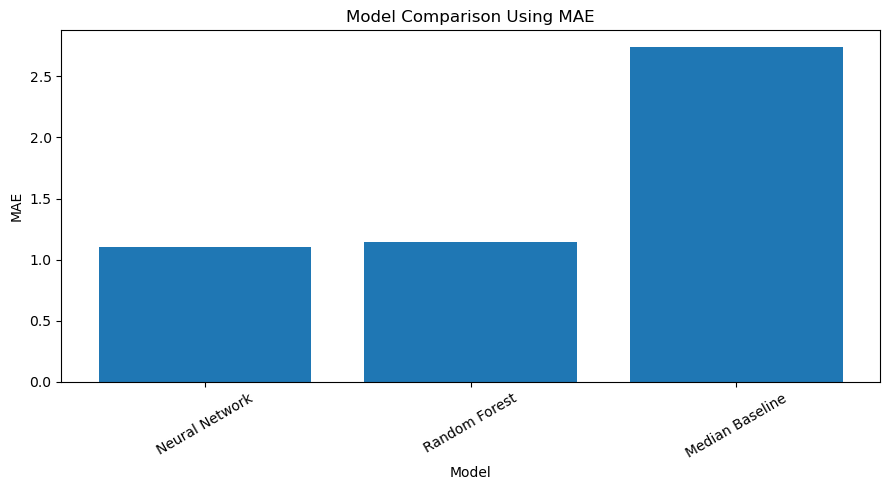

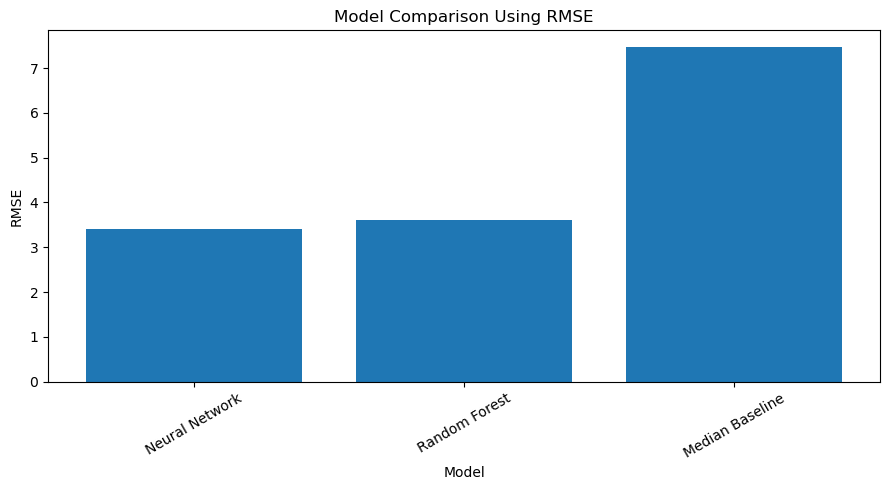

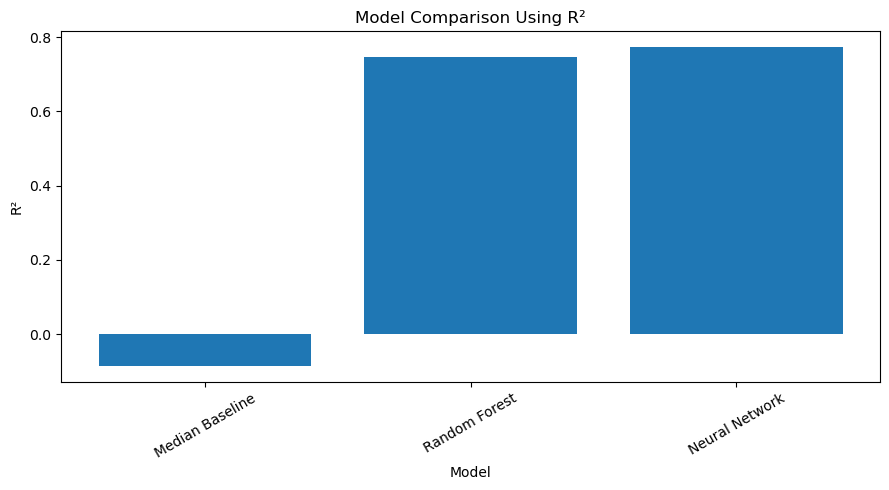

In [161]:
def plot_model_comparison(results_df, metric):
    ordered_results = results_df.sort_values(metric)

    plt.figure(figsize=(9, 5))
    plt.bar(
        ordered_results["Model"],
        ordered_results[metric]
    )

    plt.title(f"Model Comparison Using {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


plot_model_comparison(model_results, "MAE")
plot_model_comparison(model_results, "RMSE")
plot_model_comparison(model_results, "R²")

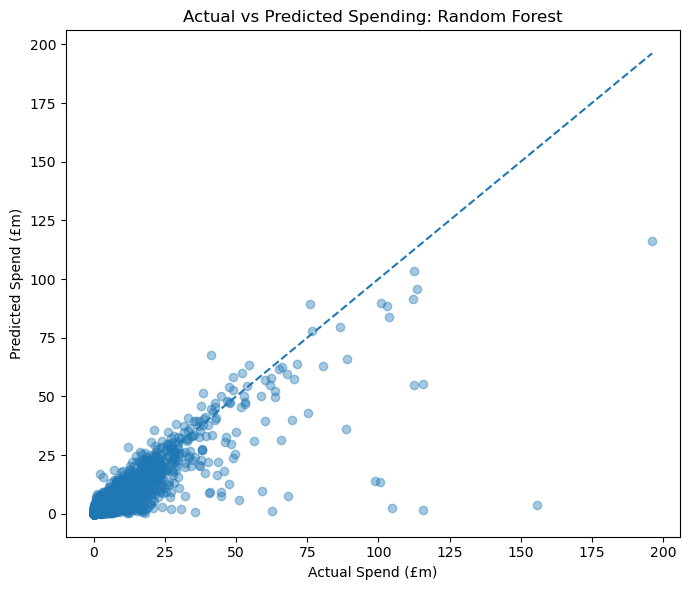

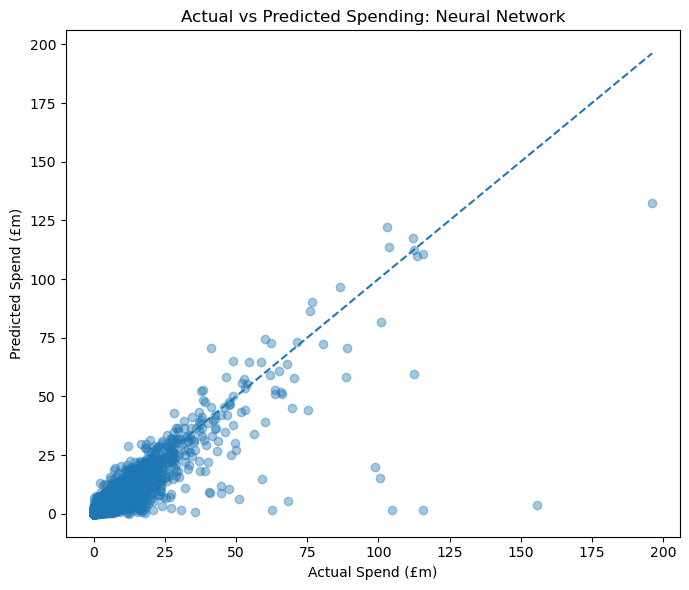

In [205]:
def plot_actual_vs_predicted(y_true, predictions, model_name):
    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_true,
        predictions,
        alpha=0.4
    )

    maximum_value = max(y_true.max(), predictions.max())

    plt.plot(
        [0, maximum_value],
        [0, maximum_value],
        linestyle="--"
    )

    plt.title(f"Actual vs Predicted Spending: {model_name}")
    plt.xlabel("Actual Spend (£m)")
    plt.ylabel("Predicted Spend (£m)")
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(
    y_test,
    rf_predictions,
    "Random Forest"
)

plot_actual_vs_predicted(
    y_test,
    nn_predictions,
    "Neural Network"
)

In [207]:
new_visitor_profile = pd.DataFrame(
    {
        "year": [2025],
        "quarter": ["July-September"],
        "market": ["France"],
        "dur_stay": ["4-7  nights"],
        "mode": ["Air"],
        "purpose": ["Holiday"],
        "Visits (000s)": [25.0],
        "Nights (000s)": [140.0],
        "sample": [40]
    }
)

new_visitor_profile

,year,quarter,market,dur_stay,mode,purpose,Visits (000s),Nights (000s),sample
0,2025,July-September,France,4-7 nights,Air,Holiday,25.0,140.0,40


In [208]:
chosen_model = random_forest_model

new_spend_prediction = chosen_model.predict(new_visitor_profile)[0]

print(
    f"Predicted spending for the new visitor profile: "
    f"£{new_spend_prediction:.2f} million"
)

Predicted spending for the new visitor profile: £16.15 million


Sentiment Analysis

In [218]:
comments_df.head()

,created_at,title,platform,text
0,2 months ago (edited),@DoshDoshington,YouTube,"Thank you, all you eagle eyed viewers, for poi..."
1,1 day ago,@MontyBellroy,YouTube,What I wouldn't give to see you build a Spaghe...
2,2 days ago (edited),@morenodk91,YouTube,anybody else than me who saw darth vader looki...
3,2 days ago,@FrogiMen13,YouTube,This is what every true adept of the machine g...
4,2 days ago,@petertomasini3294,YouTube,If only this had the randomizer mods


In [222]:
comments_df.describe()

,created_at,title,platform,text
count,2892,2892,2892,2892
unique,17,2599,1,2892
top,2 months ago,@connorm5862,YouTube,"Thank you, all you eagle eyed viewers, for poi..."
freq,2595,24,2892,1


In [224]:
comments_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2892 entries, 0 to 2956
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   created_at  2892 non-null   object
 1   title       2892 non-null   object
 2   platform    2892 non-null   object
 3   text        2892 non-null   object
dtypes: object(4)
memory usage: 113.0+ KB


In [226]:
df.duplicated().sum()

0

In [227]:
comments_df["text"] = comments_df["text"].astype(str)
print("Number of usable observations:", len(comments_df))

Number of usable observations: 2892


In [240]:
def clean_social_media_text(text):
    
    cleaned_text = str(text)
    cleaned_text = re.sub(r"http\S+|www\S+"," ",cleaned_text)
    cleaned_text = re.sub(r"@\w+"," ",cleaned_text)
    cleaned_text = re.sub(r"\s+"," ",cleaned_text)
    cleaned_text = re.sub(r"[^A-Za-z0-9]+", "_", text)

    return cleaned_text.strip()


comments_df["clean_text"] = comments_df["text"].apply(
    clean_social_media_text
)

In [241]:
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\tokak\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [242]:
sentiment_analyser = SentimentIntensityAnalyzer()

In [243]:
def calculate_sentiment(text, analyser):
    scores = analyser.polarity_scores(text)

    compound_score = scores["compound"]

    if compound_score >= 0.05:
        sentiment_label = "Positive"
    elif compound_score <= -0.05:
        sentiment_label = "Negative"
    else:
        sentiment_label = "Neutral"

    return pd.Series(
        {
            "negative_score": scores["neg"],
            "neutral_score": scores["neu"],
            "positive_score": scores["pos"],
            "compound_score": compound_score,
            "sentiment": sentiment_label
        }
    )

In [245]:
sentiment_scores = comments_df["clean_text"].apply(
    lambda text: calculate_sentiment(
        text,
        sentiment_analyser
    )
)

comments_df = pd.concat(
    [comments_df, sentiment_scores],
    axis=1
)

comments_df.head()

,created_at,title,platform,text,clean_text,negative_score,neutral_score,positive_score,compound_score,sentiment
0,2 months ago (edited),@DoshDoshington,YouTube,"Thank you, all you eagle eyed viewers, for poi...",Thank_you_all_you_eagle_eyed_viewers_for_point...,0.0,1.0,0.0,0.0,Neutral
1,1 day ago,@MontyBellroy,YouTube,What I wouldn't give to see you build a Spaghe...,What_I_wouldn_t_give_to_see_you_build_a_Spaghe...,0.0,1.0,0.0,0.0,Neutral
2,2 days ago (edited),@morenodk91,YouTube,anybody else than me who saw darth vader looki...,anybody_else_than_me_who_saw_darth_vader_looki...,0.0,1.0,0.0,0.0,Neutral
3,2 days ago,@FrogiMen13,YouTube,This is what every true adept of the machine g...,This_is_what_every_true_adept_of_the_machine_g...,0.0,1.0,0.0,0.0,Neutral
4,2 days ago,@petertomasini3294,YouTube,If only this had the randomizer mods,If_only_this_had_the_randomizer_mods,0.0,1.0,0.0,0.0,Neutral


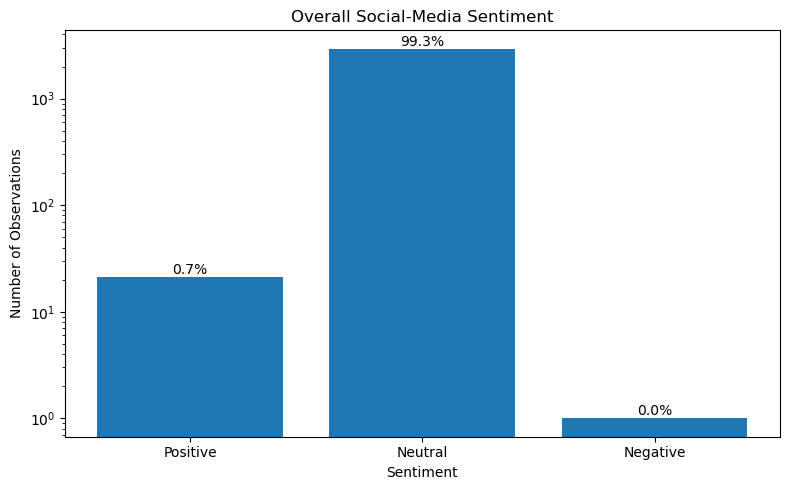

In [253]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    sentiment_summary["Sentiment"],
    sentiment_summary["Count"]
)

plt.yscale("log")
plt.title("Overall Social-Media Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Observations")

for bar, percentage in zip(
    bars,
    sentiment_summary["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [247]:
comments_df.groupby("sentiment").size().reset_index(name="count")

,sentiment,count
0,Negative,1
1,Neutral,2935
2,Positive,21


In [248]:
comments_df[comments_df["sentiment"] == "Negative"]

,created_at,title,platform,text,clean_text,negative_score,neutral_score,positive_score,compound_score,sentiment
2668,2 months ago,@RoseQueen--27,YouTube,scary,scary,1.0,0.0,0.0,-0.4939,Negative


In [249]:
comments_df[comments_df["sentiment"] == "Positive"]

,created_at,title,platform,text,clean_text,negative_score,neutral_score,positive_score,compound_score,sentiment
133,1 month ago,@5OLiBB7,YouTube,beautiful,beautiful,0.0,0.0,1.0,0.5994,Positive
360,2 months ago,@davesidious2845,YouTube,Masterpiece,Masterpiece,0.0,0.0,1.0,0.6249,Positive
370,2 months ago,@kaozmarine,YouTube,Perfection,Perfection,0.0,0.0,1.0,0.5719,Positive
460,2 months ago,@ihavenoname3770,YouTube,lmao,lmao,0.0,0.0,1.0,0.5994,Positive
529,2 months ago,@mabakalox2353,YouTube,Satisfaction,Satisfaction,0.0,0.0,1.0,0.4404,Positive
582,2 months ago,@portermoore6606,YouTube,Beautiful,Beautiful,0.0,0.0,1.0,0.5994,Positive
919,2 months ago,@vladyslavpavlov6408,YouTube,Beautiful,Beautiful,0.0,0.0,1.0,0.5994,Positive
965,2 months ago,@qlerty6218,YouTube,wonderful,wonderful,0.0,0.0,1.0,0.5719,Positive
1115,2 months ago,@99splashing,YouTube,Beautiful,Beautiful,0.0,0.0,1.0,0.5994,Positive
1309,2 months ago,@DanSher,YouTube,Beautiful,Beautiful,0.0,0.0,1.0,0.5994,Positive
